In [1]:
import sklearn
from pathlib import Path
import tarfile
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from zlib import crc32
from sklearn.model_selection import train_test_split
from pandas.plotting import scatter_matrix #To plot correlations
from sklearn.impute import SimpleImputer #To fill null with values like median
from sklearn.preprocessing import OrdinalEncoder #to convert text attribute into numerical
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector,make_column_transformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

# ADD THIS ENTIRE CLASS FIRST
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
        
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

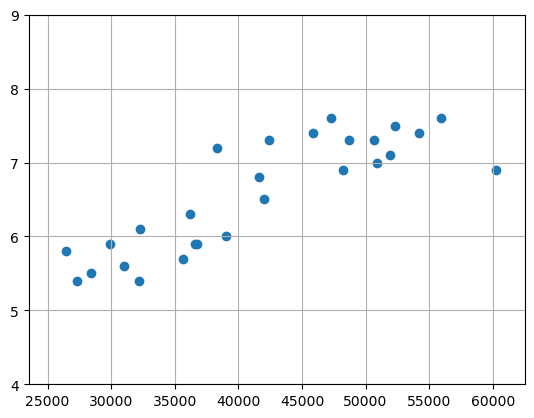

[[6.01610329]]


In [2]:
#Download the data
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")#string concat and converting normal text into a dataframe to fetched by pandas
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

#Visualize the data
plt.scatter(X,y)
plt.grid(True)
plt.axis([23_500,62_500,4,9])
plt.show()

#Training the data
model = LinearRegression()
model.fit(X,y)

#Predicting peurto rica's life satisafaction from their GDP in 2020
X_new = [[33_442.8]]
y_new = model.predict(X_new)
print(y_new)

In [3]:
#Getting the data :

def load_housing_data():
    path = Path("Datasets/housing.tgz")
    if not path.is_file():
        Path("Datasets").mkdir(parents=True, exist_ok=True)
        Url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(Url,path)
        with tarfile.open(path) as housing_path:
            housing_path.extractall(path="Datasets")#path is parameter showing where to store this file.
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

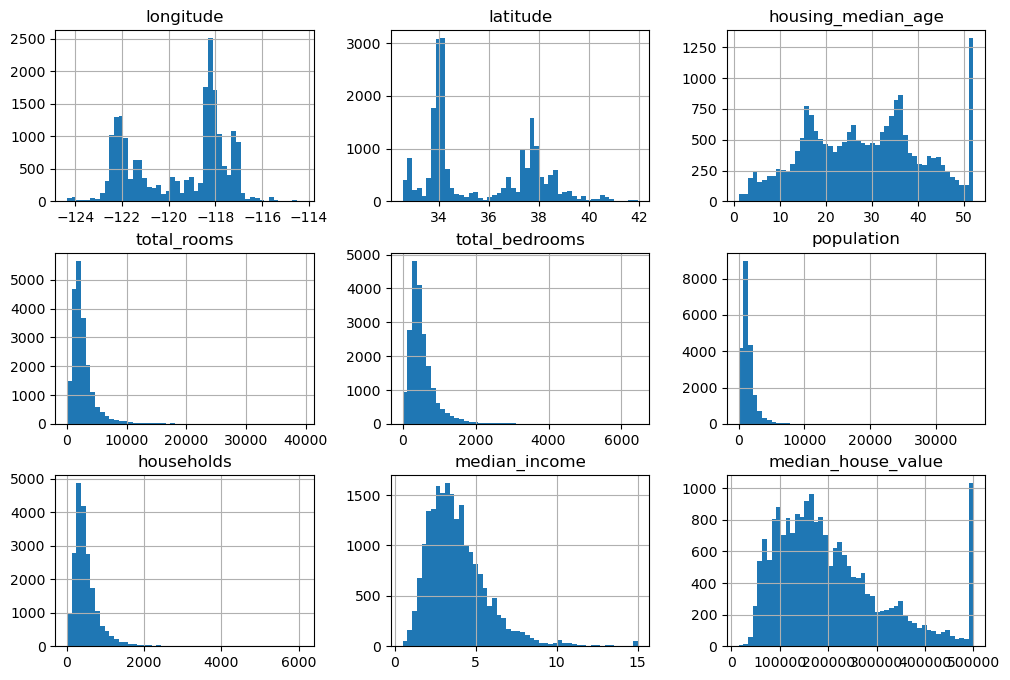

In [4]:
housing.head() #provides first five rows of data

housing.info() #provides columns, non null value count, dtype, range index, class

housing["ocean_proximity"].value_counts() #provides all values of categorical data

housing.describe() #provides numerical attributes: mean,med,mode,standard deviation,max,quartile percentile(till this point that % value lies.

#Note: 25 percentile is first quartile and 75 is third quartile.

housing.hist(bins=50,figsize=(12,8))

In [5]:
#Creating a test set theoritically

def shuffle_and_split(data,test_ratio,rng):
    shuffle_indices = rng.permutation(len(data))
    test_split = int(len(data)*test_ratio)
    train_set = shuffle_indices[:test_split]
    test_set = shuffle_indices[test_split:]
    return data.iloc[train_set],data.iloc[test_set]
    
rng = np.random.default_rng()
train_set, test_set = shuffle_and_split(housing,0.2,rng)
print(len(train_set))
print(len(test_set))

#Creating a test set that will remain same after updation
def is_id_in_the_test_set(identifier,test_ratio):
    return crc32(np.int64(identifier))<2**32*test_ratio

def split_data(data,test_ratio,id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_ : is_id_in_the_test_set(id_,test_ratio))
    return data.loc[~in_test_set],data.loc[in_test_set]
    
housing_with_id = housing.copy()    
housing_with_id["id"] = (housing["longitude"]*1000 + housing["latitude"])
train_set,test_set = split_data(housing_with_id,0.2,"id")
print(train_set)

4128
16512
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_in

In [6]:
#Creating test set using scikit-learn from random sampling ,stratified can be done here too.
train_set,test_set = train_test_split(housing,test_size=0.2,random_state=42)

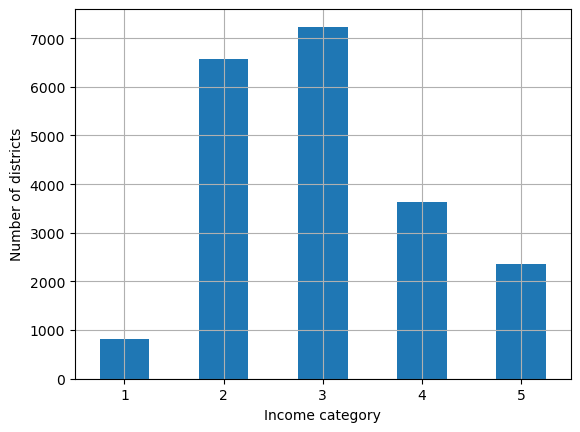

In [7]:
#Creating stratified sampling
housing["income_cat"] = pd.cut(housing["median_income"],bins = [0,1.5,3,4.5,6,np.inf],labels = [1,2,3,4,5])

cat_count = housing["income_cat"].value_counts().sort_index()
cat_count.plot.bar(rot=0,grid=True)
plt.xlabel('Income category')
plt.ylabel('Number of districts')
plt.show()


In [8]:
strat_train_set, strat_test_set = train_test_split(
    housing, 
    test_size=0.2, 
    stratify=housing["income_cat"], 
    random_state=42
)
#It shows the proportions of how much test set is taken from each category.
for set_ in(strat_train_set,strat_test_set):
     set_.drop("income_cat",axis=1,inplace=True)

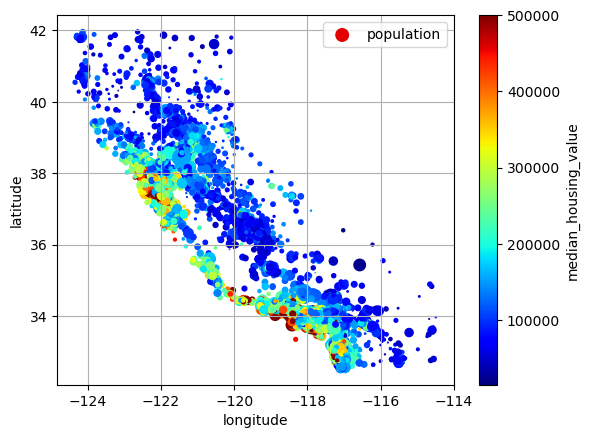

In [14]:
#copy of training data
housing_train = strat_train_set.drop("median_house_value", axis=1).copy()
housing_labels = strat_train_set["median_house_value"].copy()
x =housing_train["longitude"]
y = housing_train["latitude"]
scatter = plt.scatter(x,y,s=housing_train["population"]/100,cmap="jet",c=housing_labels,label='population')
plt.grid(True)
plt.legend()
plt.colorbar(scatter,label='median_housing_value')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()

array([[<Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>],
       [<Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>],
       [<Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='housing_median_age', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housing_median_age'>],
       [<Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='housing_media

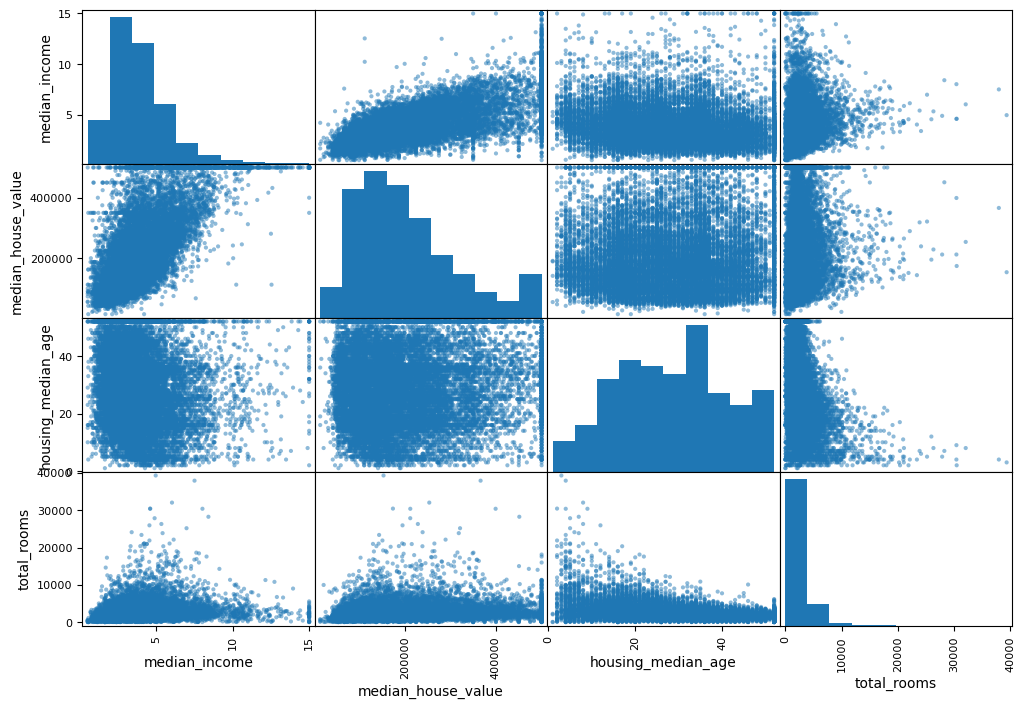

In [16]:
#Look for correlation between  numeric attributes.
cor_coeff = strat_train_set.corr(numeric_only=True)
cor_coeff["median_house_value"].sort_values(ascending=False)

#Finding correlation using pandas
attributes = ["median_income","median_house_value","housing_median_age","total_rooms"]
scatter_matrix(strat_train_set[attributes],figsize=(12,8))


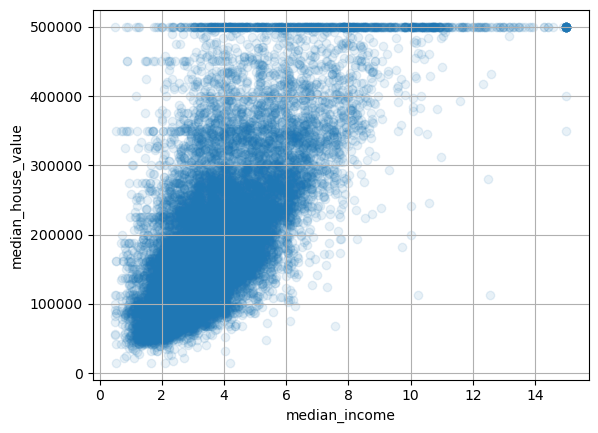

In [36]:
#Observable that: as median income increases house value increases so this data seems more model-friendly.
plt.scatter(x=housing_train['median_income'],y=housing_labels,alpha=0.1)
plt.grid(True)
plt.xlabel('median_income')
plt.ylabel('median_house_value')
plt.show()

In [21]:
#add new attributes
housing_train["rooms_per_house"] = housing_train["total_rooms"] / housing_train["households"]
housing_train["bedrooms_ratio"] = housing_train["total_bedrooms"] / housing_train["total_rooms"]
housing_train["people_per_house"] = housing_train["population"] / housing_train["households"]

housing_train_with_labels = housing_train.copy()
housing_train_with_labels["median_house_value"] = housing_labels

corr_matrix = housing_train_with_labels.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

In [ ]:
#Clean the dataset:
imputer = SimpleImputer(strategy = "median")
housing_num = housing_train.select_dtypes(include = [np.number])
imputer.fit(housing_num)
X = imputer.transform(housing_num)#filled null values with median

#To convert ndarray into dataframe
housing_tr = pd.DataFrame(X,columns = housing_num.columns,index = housing_num.index)
housing_cat = housing_train[["ocean_proximity"]]

#Converting text into code values
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

#performing one hot encoding
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [ ]:

#This feature helps avoid column mistmatches, and it’s also quite useful when debugging. will do later.

In [22]:
#feature scaling using normalization
# min_max_scaler = MinMaxScaler(feature_range=(-1,1))
# housing_min_max_scaled = min_max_scaler.fit_transform(housing_num)
housing_num = housing_train.select_dtypes(include=[np.number])
#Standardization
std_scaled = StandardScaler()
housing_num_std_scaled = std_scaled.fit_transform(housing_num)

#applying rbf gaussian distribution
age_simil_35 = rbf_kernel(housing_num[["housing_median_age"]],[[35]],gamma=0.1)

In [23]:
#Using transformed target regressor to avoid scaling mismatches.
some_new_data = housing_train[["median_income"]].iloc[:5] # pretend this is new data

model = TransformedTargetRegressor(LinearRegression(),transformer = StandardScaler())
model.fit(housing_train[['median_income']],housing_labels)
predictions = model.predict(some_new_data)

In [24]:
#writing own transformers for function like applying log for heavy tailed distributions. will come back for it later.
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing_train[["population"]])
rbf_transformer = FunctionTransformer(rbf_kernel,
 kw_args=dict(Y=[[35.]],
gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
 kw_args=dict(Y=[sf_coords],
gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude",
"longitude"]])


In [25]:
#Transformation pipelines
num_pipeline = Pipeline([
    ("impute",SimpleImputer(strategy = "median")),
    ("scale",StandardScaler()),
])

#for visualization
sklearn.set_config(display="diagram")

In [34]:
# To separate num and cat attributes and basically handling the columns.
housing_num_prepared = num_pipeline.fit_transform(housing_num)
df_housing_num_prepared = pd.DataFrame(housing_num_prepared,columns=num_pipeline.get_feature_names_out(),index=housing_num.index)
num_attribs = ["longitude", "latitude", "housing_median_age",
"total_rooms",
 "total_bedrooms", "population", "households",
"median_income"]
cat_attribs = ["ocean_proximity"]
cat_pipeline = make_pipeline(
 SimpleImputer(strategy="most_frequent"),
 OneHotEncoder(handle_unknown="ignore"))
preprocessing = make_column_transformer(
 (num_pipeline, make_column_selector(dtype_include=np.number)),
 (cat_pipeline, make_column_selector(dtype_include=object)),
)
housing_prepared = preprocessing.fit_transform(housing_train)


In [27]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]
    
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"] 

def ratio_pipeline():
 return make_pipeline(
     SimpleImputer(strategy="median"),
     FunctionTransformer(column_ratio,
feature_names_out=ratio_name),
     StandardScaler())
    
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.,
random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

preprocessing = ColumnTransformer([
 ("bedrooms", ratio_pipeline(), ["total_bedrooms",
"total_rooms"]),
 ("rooms_per_house", ratio_pipeline(), ["total_rooms",
"households"]),
 ("people_per_house", ratio_pipeline(), ["population",
"households"]),
 ("log", log_pipeline, ["total_bedrooms", "total_rooms",
"population",
 "households", "median_income"]),
 ("geo", cluster_simil, ["latitude", "longitude"]),
 ("cat", cat_pipeline,
make_column_selector(dtype_include=object)),
 ],
 remainder=default_num_pipeline)

In [35]:
#Select and train a model
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing_train,housing_labels)

#predicting the training set
housing_predictions = lin_reg.predict(housing_train)

#first 5 sets
housing_predictions[:5].round(-2)


array([281800., 333300., 117000., 104900., 309100.])

In [28]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [29]:
# Check what columns you have
print(strat_train_set.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [40]:
housing_predictions[:5].round(-2)


array([281800., 333300., 117000., 104900., 309100.])